In [5]:
# %%
from core.Det import Det, DetData
import numpy as np
import matplotlib.pyplot as plt
from rich.table import Table
from rich import print
from hdf5storage import loadmat
import time
from core.AcqFunc import *

In [6]:
srv = DetData("10.20.99.2",50099)
dets = srv.findDet()
print(dets)
det = list(dets.items())[0][1]
srv.listen()

{'10.20.99.1': <core.Det.Det.Det object at 0x0000023FB32B8CD0>}

In [7]:
# %% 状态信息
def dictPrint(d: dict, title="", k="", v=""):
    t = Table(title=title)
    t.add_column(k)
    t.add_column(v)
    [t.add_row(k, str(v)) for k, v in d.items()]
    print(t)
dictPrint(det.statusTemperature(), "温度")
dictPrint(det.statusPosition(0.0375), "位置")
dictPrint(det.statusPower(), "电源")
dictPrint(det.statusPowerSwitch(), "开关")
dictPrint(det.statusFanSpeed(), "风扇")

           温度            
┏━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃            ┃            ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ boardNum   │ 3          │
│ temperIO_0 │ 32.5       │
│ temperIO_1 │ 33.75      │
│ temper0_0  │ 33.640625  │
│ temper0_1  │ 34.78125   │
│ temper0_2  │ 36.328125  │
│ temper0_3  │ 36.921875  │
│ temper1_0  │ 33.265625  │
│ temper1_1  │ 34.2578125 │
│ temper1_2  │ 35.8828125 │
│ temper1_3  │ 37.21875   │
│ temper2_0  │ 32.359375  │
│ temper2_1  │ 33.7890625 │
│ temper2_2  │ 35.5078125 │
│ temper2_3  │ 36.4921875 │
└────────────┴────────────┘

       位置       
┏━━━━━━━┳━━━━━━━━┓
┃       ┃        ┃
┡━━━━━━━╇━━━━━━━━┩
│ pos0A │ False  │
│ pos0B │ True   │
│ pos0  │ 0.0375 │
│ pos1A │ False  │
│ pos1B │ False  │
│ pos1  │ 0.0    │
└───────┴────────┘

       电源        
┏━━━━━━━━━┳━━━━━━━┓
┃         ┃       ┃
┡━━━━━━━━━╇━━━━━━━┩
│ voltage │ 23.92 │
│ currnet │ 1.666 │
│ power   │ 39.85 │
└─────────┴───────┘

            开关             
┏━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃        ┃                  ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ vcc12  │ True             │
│ laser1 │ False            │
│ laser0 │ False            │
│ vdd25  │ 11111111         │
│ opa    │ 1111111111111111 │
│ vbias  │ 11111111         │
└────────┴──────────────────┘

        风扇        
┏━━━━━━━━━━━┳━━━━━━┓
┃           ┃      ┃
┡━━━━━━━━━━━╇━━━━━━┩
│ fanNum    │ 3    │
│ fanSpeed0 │ 1461 │
│ fanSpeed1 │ 1445 │
│ fanSpeed2 │ 1462 │
└───────────┴──────┘

In [8]:
# %% 电源及参数设置
det.setPositionConfig([
    {"pos": 0, "en": 1, "polarity": 0, "clearPos": 1, "zeroShift": 0},
    {"pos": 1, "en": 0, "polarity": 0, "clearPos": 1, "zeroShift": 0}])
det.setPowerSwitch({
    "laser1": 0, "laser0": 0, "opa": 1, "vbias": 1, "vcc12": 1, "vdd25": 1})
det.DetectRegSet(0x0018, 0x600003FF)
det.setWinNum(4)

detector run

test233

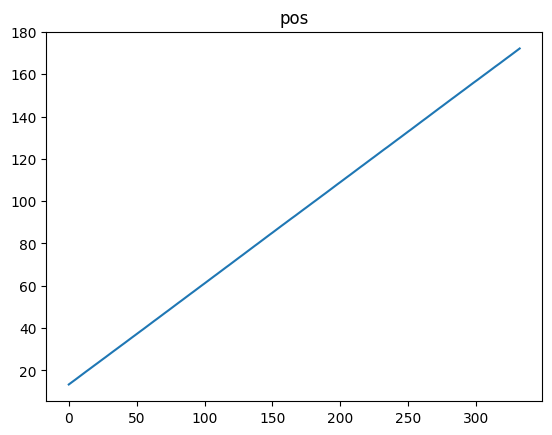

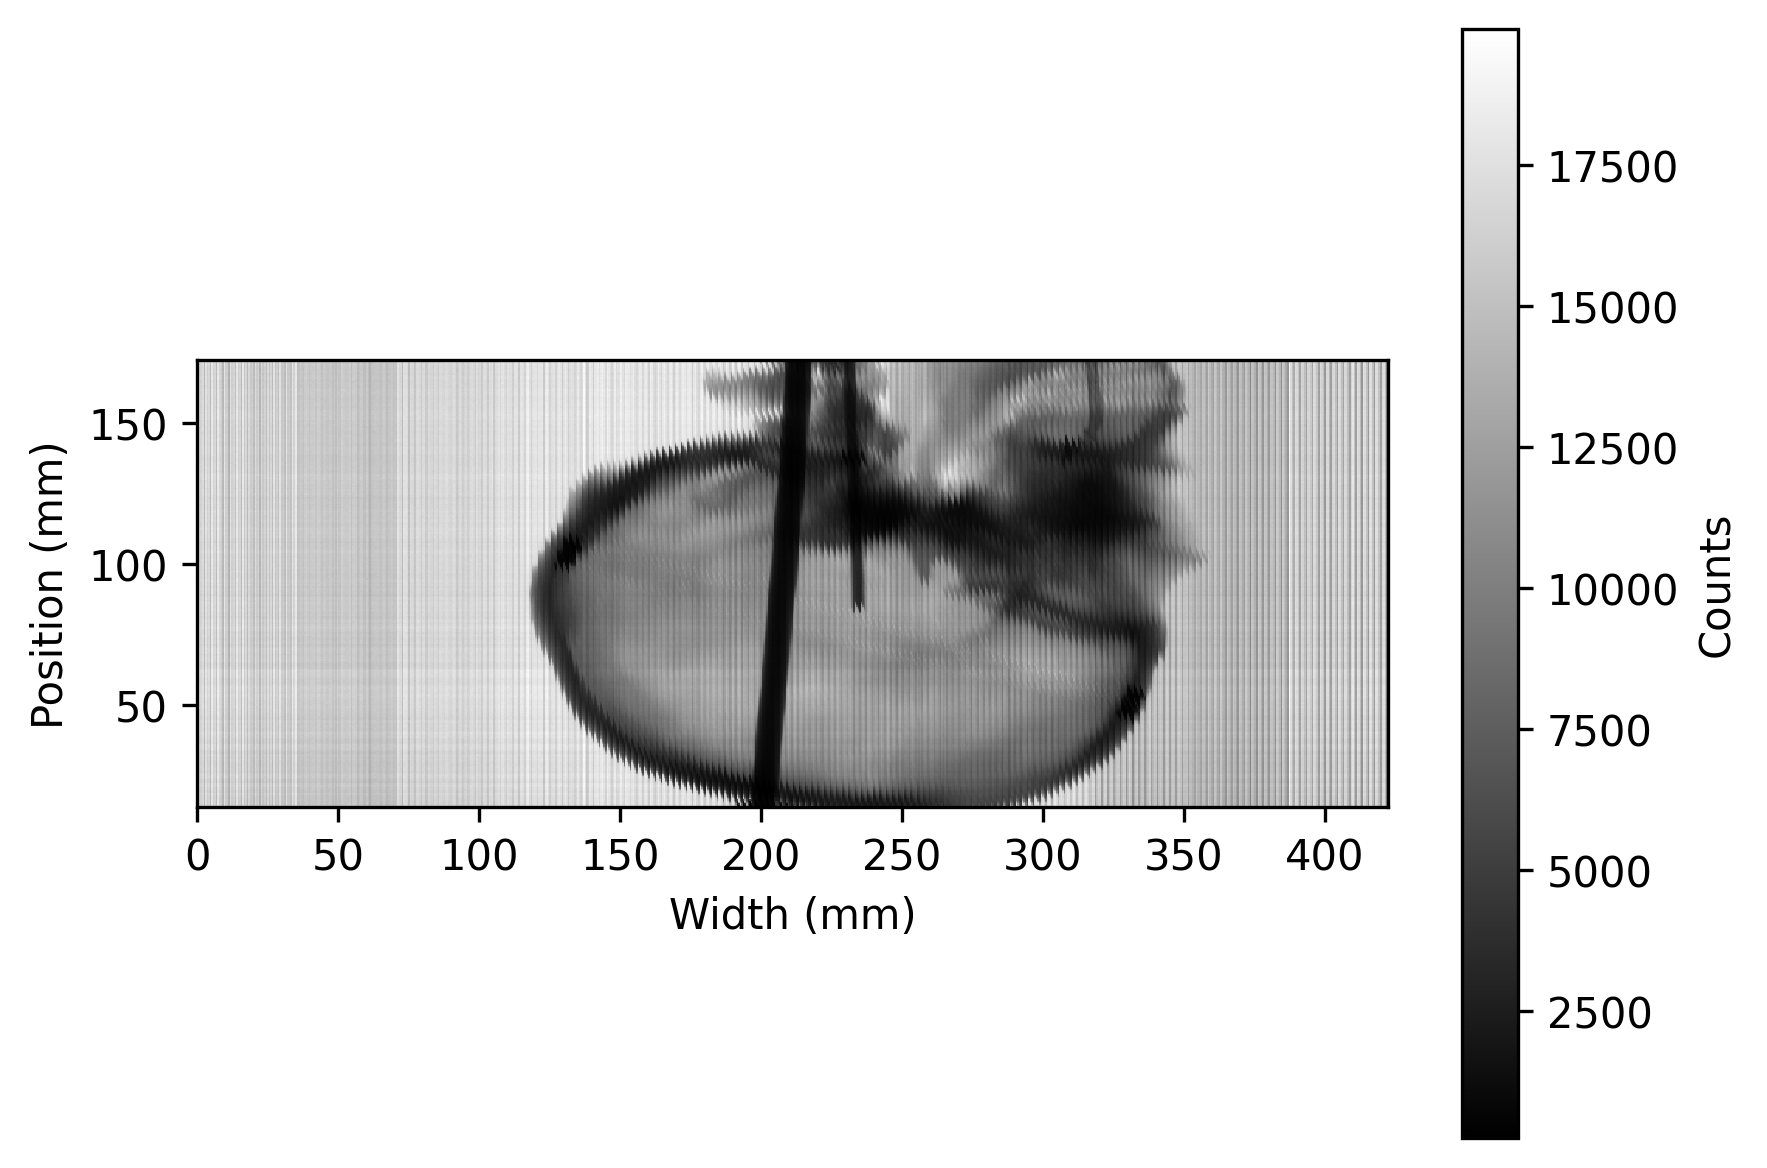

In [9]:
for i in range(1):
    # tube = f""
    # tube = f"_70kV_10mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    # speed = f"_150mmps"
    name = f"test233"

    subname = f"{name}"
    det.setWinRange(0, 0, 80)
    # time.sleep(4)
    print("detector run")
    # time.sleep(1)
    data = histAcqNoMove(det, cnt=None, time=4, interval = int(12 * 10))
    saveHist(data, subname, None)
    print(subname)
    showHist(
        data,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )

In [ ]:
for i in range(1):
    # tube = f""
    tube = f"_75kV_110mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    filter = f"_25mmAl"
    speed = f"_37.5mmps"
    freq = 500
    name = f"test2{speed}{filter}{tube}_{freq}hz"

    subname = f"{name}"
    det.setWinRange(0, 0, 99)
    det.setWinRange(1, 6, 21)
    det.setWinRange(2, 22, 40)
    det.setWinRange(3, 0, 90)
    print("detector run")
    data = thrAcqNoMove(det, cnt=None, time=8, interval = int(1000/freq * 10))
    saveThr(data, subname)
    print(subname)
    data2 = {
        "pos0h": data["pos0h"],
        "data": data["data"].reshape((data["data"].shape[0], -1, data["data"].shape[3]))
    }
    showHist(
        data2,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )